
# K-means : comprendre et appliquer le clustering

> **Objectif du notebook**  
> Comprendre pas à pas le fonctionnement de l'algorithme **K-means**, d'abord « à la main » sur un jeu de données 2D, puis avec `scikit-learn`. Nous verrons également comment choisir le nombre de groupes avec la **méthode du coude**.

## 1. Le problème : regrouper des observations

Jusqu'à présent, nous avons principalement travaillé avec des problèmes **supervisés** : nous disposions d'une variable cible à prédire.

Avec K-means, nous sommes dans le cadre de l'**apprentissage non supervisé** :

- nous avons des observations ;
- nous disposons de variables décrivant ces observations ;
- nous **n'avons pas de variable cible** indiquant le groupe auquel appartient chaque observation ;
- l'algorithme cherche lui-même des groupes d'observations similaires.

### Exemple métier

Imaginons une entreprise d'e-commerce qui dispose d'informations sur ses clients et souhaite identifier des profils d'acheteurs à partir de deux indicateurs :

- `revenu_annuel` : revenu annuel du client (en k€) ;
- `score_depense` : score d'appétence aux achats attribuable au client (de 1 à 100).

L'objectif est d'identifier automatiquement des typologies de clients comme :

- clients à revenu modéré mais à fort potentiel d'achat (« acheteurs impulsifs ») ;
- clients à faible revenu et faibles dépenses (« acheteurs occasionnels / économes ») ;
- clients à fort revenu et fortes dépenses (« clients VIP »).

**Attention :** ces catégories ne sont pas connues à l'avance. C'est précisément ce que nous cherchons à découvrir.

## 2. Importer les bibliothèques

Nous utiliserons :

- `numpy` pour les calculs numériques ;
- `pandas` pour manipuler les données ;
- `matplotlib` pour les visualisations ;
- `scikit-learn` pour l'implémentation de K-means.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## 3. Construire un petit jeu de données

Pour comprendre l'algorithme, nous allons commencer avec un jeu de données de 15 clients bien répartis dans l'espace 2D.


In [2]:
data = pd.DataFrame({
    'revenu_annuel': [
        15, 18, 20, 22, 25,  # Groupe 1 : Revenu faible, Dépense faible
        18, 22, 25, 28, 30,  # Groupe 2 : Revenu faible, Dépense élevée
        75, 80, 85, 88, 90   # Groupe 3 : Revenu élevé, Dépense élevée
    ],
    'score_depense': [
        12, 20, 15, 25, 18,  # Groupe 1
        78, 85, 80, 92, 75,  # Groupe 2
        82, 88, 95, 80, 90   # Groupe 3
    ]
})

data

,revenu_annuel,score_depense
0,15,12
1,18,20
2,20,15
3,22,25
4,25,18
5,18,78
6,22,85
7,25,80
8,28,92
9,30,75


Visualisons le jeu de données avant d'appliquer tout algorithme.


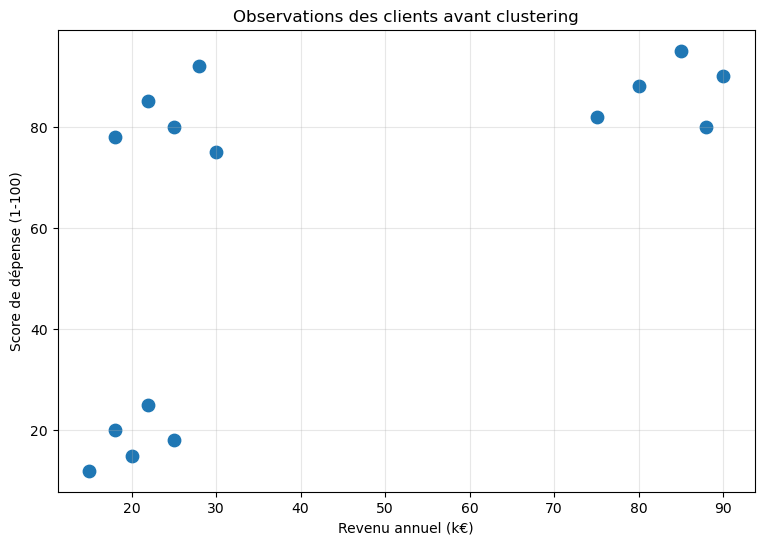

In [3]:
plt.figure(figsize=(9, 6))

plt.scatter(
    data['revenu_annuel'],
    data['score_depense'],
    s=80
)

plt.xlabel('Revenu annuel (k€)')
plt.ylabel('Score de dépense (1-100)')
plt.title('Observations des clients avant clustering')
plt.grid(alpha=0.3)

plt.show()

### Première observation

Visuellement, on distingue assez facilement **trois groupes distincts** répartis dans l'espace.

Mais un algorithme ne « voit » pas directement les groupes comme nous.

Il doit déterminer :

1. où placer les centres des groupes ;
2. à quel groupe rattacher chaque observation ;
3. comment améliorer progressivement ces groupes.

C'est le principe de K-means.

# 4. L'idée générale de K-means

K-means cherche à partitionner les observations en **K groupes**.

Le `K` correspond donc au nombre de groupes que nous demandons à l'algorithme de construire.

Par exemple :

```text
K = 2  →  2 groupes
K = 3  →  3 groupes
K = 4  →  4 groupes
```

L'algorithme repose sur une idée très simple :

> Une observation est affectée au centre de groupe dont elle est la plus proche.

Les centres des groupes sont appelés **centroïdes**.

# 5. Les étapes de l'algorithme

Le fonctionnement général est :

```text
1. Choisir K centroïdes initiaux
2. Affecter chaque observation
   au centroïde le plus proche
3. Recalculer chaque centroïde
   comme la moyenne des observations
   qui lui sont associées
4. Recommencer les étapes 2 et 3
5. Arrêter lorsque les centroïdes
   ne changent quasiment plus
```

# 6. Pourquoi parle-t-on de « means » ?

Le mot **means** signifie « moyennes ».

Après avoir affecté les observations à un groupe, K-means calcule la moyenne des coordonnées des observations du groupe.

Prenons trois points du premier groupe :

```text
(15, 12)
(18, 20)
(20, 15)
```

Le centroïde est :

```text
x = (15 + 18 + 20) / 3 = 17.67
y = (12 + 20 + 15) / 3 = 15.67
```

Le nouveau centroïde est donc approximativement :

```text
(17.67, 15.67)
```

# 7. Choisir K

Pour notre exemple, nous allons choisir :

In [4]:
k = 3

Ce choix est volontaire. Nous savons que le jeu de données pédagogique contient trois groupes. Plus loin, nous verrons comment choisir `K` sur un problème réel.

# 8. Étape 1 : initialiser les centroïdes

Pour comprendre le mécanisme, choisissons trois centroïdes de départ un peu décalés par rapport aux vrais groupes.

In [5]:
centroids = np.array([
    [20, 30],
    [40, 60],
    [70, 70]
])

centroids

array([[20, 30],
       [40, 60],
       [70, 70]])

Visualisons-les.

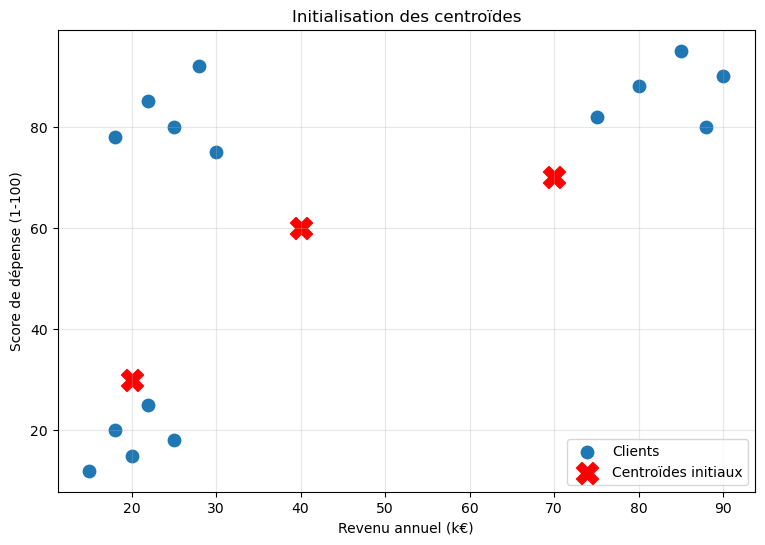

In [6]:
plt.figure(figsize=(9, 6))

plt.scatter(
    data['revenu_annuel'],
    data['score_depense'],
    s=80,
    label='Clients'
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=250,
    color='red',
    label='Centroïdes initiaux'
)

plt.xlabel('Revenu annuel (k€)')
plt.ylabel('Score de dépense (1-100)')
plt.title('Initialisation des centroïdes')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Dans cet exemple, les centroïdes sont volontairement choisis de manière imparfaite afin de visualiser leur déplacement.

Dans une vraie exécution, K-means utilise une stratégie d'initialisation automatique (ex: `k-means++`).

# 9. Étape 2 : calculer les distances

K-means utilise généralement la **distance euclidienne**.

Pour deux points :
```text
A = (x1, y1)
B = (x2, y2)
```

la distance est :

```text
d(A, B) = √((x2 - x1)² + (y2 - y1)²)
```

Prenons la première observation $A = (15, 12)$ et le centroïde $C_1 = (20, 30)$ :

```text
d(A, C1) = √((20 - 15)² + (30 - 12)²)
= √(25 + 324)
= √349 ≈ 18.68
```

# 10. Calculer les distances pour toutes les observations

Nous pouvons reproduire cette étape avec Python.

In [7]:
points = data[
    ['revenu_annuel', 'score_depense']
].to_numpy()

distances = np.linalg.norm(
    points[:, np.newaxis, :] - centroids[np.newaxis, :, :],
    axis=2
)

distances

array([[18.68154169, 54.12023651, 79.93122043],
       [10.19803903, 45.65084884, 72.13875519],
       [15.        , 49.24428901, 74.33034374],
       [ 5.38516481, 39.35733731, 65.7951366 ],
       [13.        , 44.59820624, 68.76772499],
       [48.0416486 , 28.42534081, 52.61178575],
       [55.03635162, 30.8058436 , 50.28916384],
       [50.24937811, 25.        , 46.09772229],
       [62.51399843, 34.17601498, 47.41307836],
       [46.09772229, 18.02775638, 40.31128874],
       [75.69015788, 41.34005322, 13.        ],
       [83.45058418, 48.82622246, 20.59126028],
       [91.92388155, 57.00877125, 29.15475947],
       [84.40379138, 52.        , 20.59126028],
       [92.19544457, 58.30951895, 28.28427125]])

Chaque ligne correspond à une observation.
Chaque colonne correspond à un centroïde.

Par exemple :

```text
                 C1       C2       C3
Observation 1   18.68    55.71    79.88
Observation 2   10.20    45.87    72.80
...
```

# 11. Étape 3 : affecter chaque observation

Pour chaque observation, nous conservons le centroïde correspondant à la plus petite distance.

In [8]:
labels = np.argmin(distances, axis=1)

labels

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2])

Les valeurs `0`, `1` et `2` représentent respectivement les trois groupes.

Nous pouvons ajouter cette information au DataFrame.

In [9]:
data['cluster'] = labels

data

,revenu_annuel,score_depense,cluster
0,15,12,0
1,18,20,0
2,20,15,0
3,22,25,0
4,25,18,0
5,18,78,1
6,22,85,1
7,25,80,1
8,28,92,1
9,30,75,1


# 12. Visualiser les groupes

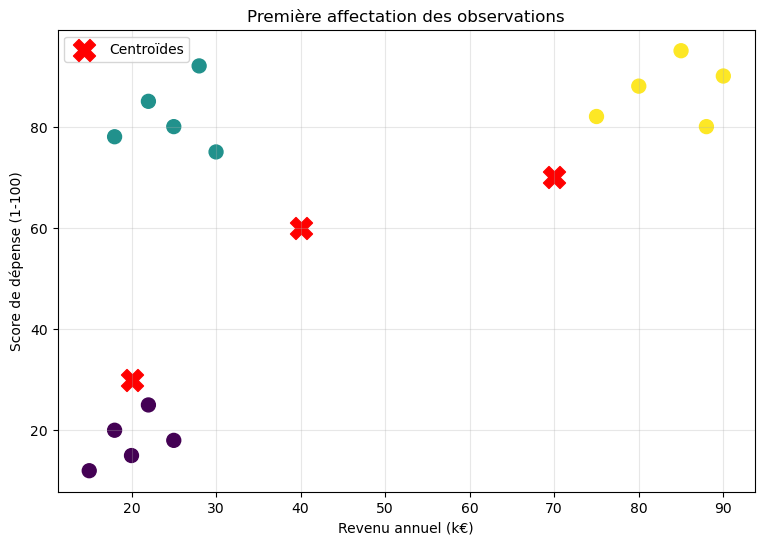

In [10]:
plt.figure(figsize=(9, 6))

plt.scatter(
    data['revenu_annuel'],
    data['score_depense'],
    c=data['cluster'],
    s=100,
    cmap='viridis'
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=250,
    color='red',
    label='Centroïdes'
)

plt.xlabel('Revenu annuel (k€)')
plt.ylabel('Score de dépense (1-100)')
plt.title('Première affectation des observations')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Nous avons maintenant effectué une première itération de K-means. Mais l'algorithme n'est pas encore terminé.

# 13. Étape 4 : recalculer les centroïdes

Pour chaque groupe, nous calculons la moyenne des coordonnées des observations qui lui appartiennent.

In [11]:
new_centroids = np.array([
    points[labels == cluster_id].mean(axis=0)
    for cluster_id in range(k)
])

new_centroids

array([[20. , 18. ],
       [24.6, 82. ],
       [83.6, 87. ]])

Comparez les anciens et les nouveaux centroïdes :

In [12]:
print('Anciens centroïdes :')
print(centroids)

print('\nNouveaux centroïdes :')
print(new_centroids)


Anciens centroïdes :
[[20 30]
 [40 60]
 [70 70]]

Nouveaux centroïdes :
[[20.  18. ]
 [24.6 82. ]
 [83.6 87. ]]


On observe le principe essentiel de K-means :

> Les centroïdes se déplacent pour se rapprocher du centre réel des observations qui leur sont attribuées.

# 14. Étape 5 : recommencer

Nous pouvons maintenant prendre les nouveaux centroïdes et recommencer :

```text
Nouveaux centroïdes
        ↓
Calcul des distances
        ↓
Nouvelle affectation
        ↓
Nouveaux centroïdes
        ↓
...
```

La boucle continue jusqu'à ce que les centroïdes ne changent quasiment plus.

# 15. Implémenter une version simplifiée de K-means

Pour comprendre le principe, nous pouvons écrire nous-mêmes une version pédagogique.

In [13]:
def simple_kmeans(points, k, initial_centroids, max_iterations=100):
    """
    Implémente une version pédagogique de K-means.
    """
    centroids = initial_centroids.copy()

    for _ in range(max_iterations):
        distances = np.linalg.norm(
            points[:, np.newaxis, :] - centroids[np.newaxis, :, :],
            axis=2
        )

        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([
            points[labels == cluster_id].mean(axis=0)
            for cluster_id in range(k)
        ])

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids


Testons notre implémentation.

In [14]:
initial_centroids = np.array([
    [20, 30],
    [40, 60],
    [70, 70]
])

labels, centroids = simple_kmeans(
    points,
    k=3,
    initial_centroids=initial_centroids
)

print('Centroïdes finaux :')
print(centroids)


Centroïdes finaux :
[[20.  18. ]
 [24.6 82. ]
 [83.6 87. ]]


# 16. Visualiser le résultat final

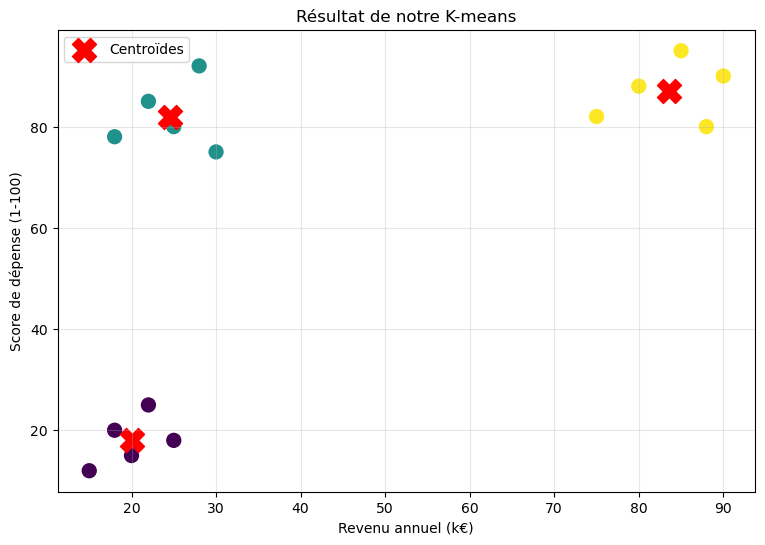

In [15]:
plt.figure(figsize=(9, 6))

plt.scatter(
    points[:, 0],
    points[:, 1],
    c=labels,
    s=100,
    cmap='viridis'
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=300,
    color='red',
    label='Centroïdes'
)

plt.xlabel('Revenu annuel (k€)')
plt.ylabel('Score de dépense (1-100)')
plt.title('Résultat de notre K-means')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


Nous avons reproduit les grandes étapes de l'algorithme.

# 17. L'objectif de K-means : minimiser l'inertie

K-means cherche à construire des groupes dont les observations sont aussi proches que possible de leur centroïde.

On cherche donc à minimiser une quantité appelée **inertie intra-classe**.

$$J = \sum_{i=1}^{n} \vert{}\vert{}x_i - \mu_{c_i}\vert{}\vert{}^2$$

avec :

* $x_i$ : une observation ;
* $c_i$ : le cluster de l'observation ;
* $\mu_{c_i}$ : le centroïde du cluster ;
* $\vert{}\vert{}x_i - \mu_{c_i}\vert{}\vert{}^2$ : la distance euclidienne au carré.

L'algorithme cherche des groupes **compacts**.

# 18. Passons à scikit-learn

Maintenant que le fonctionnement est compris, utilisons l'implémentation de `scikit-learn`.

In [16]:
model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

model.fit(points)


KMeans(n_clusters=3, n_init=10, random_state=42)

Les groupes obtenus sont accessibles avec :

In [17]:
model.labels_


array([2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=int32)

Les centroïdes sont accessibles avec :

In [18]:
model.cluster_centers_


array([[24.6, 82. ],
       [83.6, 87. ],
       [20. , 18. ]])

L'inertie finale est accessible avec :

In [19]:
model.inertia_


722.4

# 19. Visualiser K-means avec scikit-learn

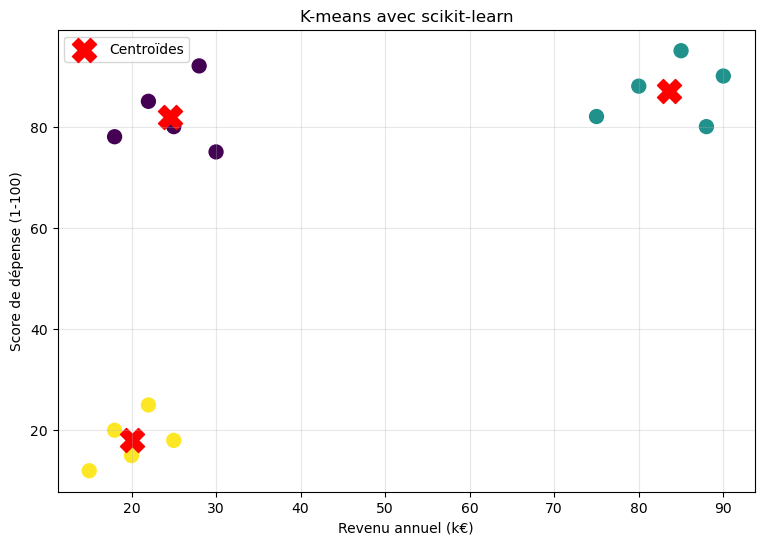

In [20]:
plt.figure(figsize=(9, 6))

plt.scatter(
    points[:, 0],
    points[:, 1],
    c=model.labels_,
    s=100,
    cmap='viridis'
)

plt.scatter(
    model.cluster_centers_[:, 0],
    model.cluster_centers_[:, 1],
    marker='X',
    s=300,
    color='red',
    label='Centroïdes'
)

plt.xlabel('Revenu annuel (k€)')
plt.ylabel('Score de dépense (1-100)')
plt.title('K-means avec scikit-learn')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# 20. Pourquoi utiliser `n_init` ?

K-means dépend de l'initialisation des centroïdes. Une mauvaise initialisation peut conduire à une solution sous-optimale (un minimum local).

Avec `n_init=10`, `scikit-learn` lance 10 initialisations différentes et conserve la meilleure solution selon l'inertie.

Le paramètre `random_state=42` permet de rendre l'expérience reproductible.

# 21. Le choix de K

Jusqu'à présent, nous avons choisi $K = 3$ parce que nous connaissions la structure de notre jeu de données.

Mais dans un problème réel, nous ne connaissons pas le nombre de groupes à l'avance. Une première approche classique est la **méthode du coude**.

# 22. La méthode du coude

L'idée est simple :

1. essayer plusieurs valeurs de `K` ;
2. entraîner un modèle K-means pour chaque valeur ;
3. récupérer l'inertie ;
4. tracer l'inertie en fonction de `K`.

L'inertie diminue lorsque `K` augmente, mais les gains deviennent progressivement moins importants. C'est ce changement de pente qui forme un **coude**.

# 23. Calculer les inerties

In [21]:
inertias = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(points)

    inertias.append(model.inertia_)


Regardons les valeurs :

In [22]:
for k, inertia in zip(range(1, 11), inertias):
    print(f'K = {k} → inertie = {inertia:.2f}')


K = 1 → inertie = 28104.27
K = 2 → inertie = 9487.40
K = 3 → inertie = 722.40
K = 4 → inertie = 570.87
K = 5 → inertie = 480.70
K = 6 → inertie = 355.17
K = 7 → inertie = 262.17
K = 8 → inertie = 173.83
K = 9 → inertie = 146.83
K = 10 → inertie = 111.17


# 24. Tracer la courbe du coude

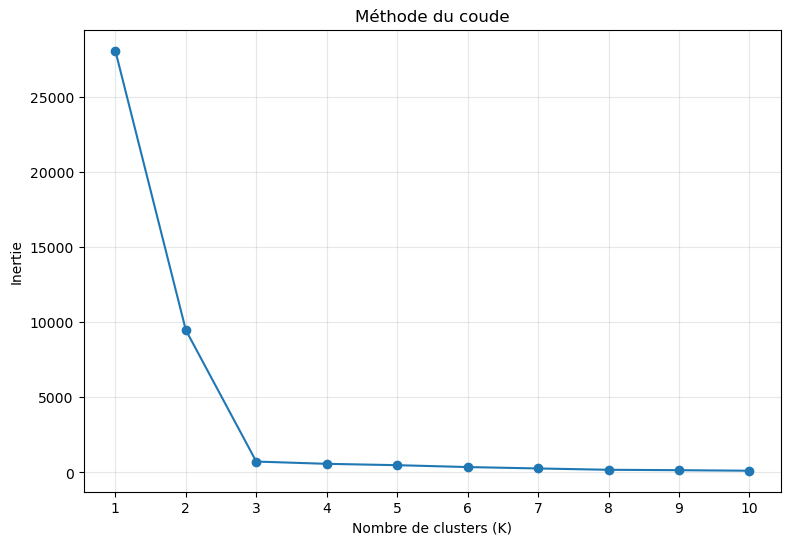

In [23]:
plt.figure(figsize=(9, 6))

plt.plot(
    range(1, 11),
    inertias,
    marker='o'
)

plt.xlabel('Nombre de clusters (K)')
plt.ylabel('Inertie')
plt.title('Méthode du coude')
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)

plt.show()


### Comment interpréter le graphique ?

Nous cherchons un point où l'inertie diminue fortement avant ce point, puis où la diminution devient beaucoup plus faible après.

Sur notre jeu de données, le coude apparaît nettement à $K = 3$.

# 25. Pourquoi l'inertie diminue-t-elle toujours ?

Si nous augmentons le nombre de clusters, nous donnons au modèle davantage de centroïdes. Les observations peuvent donc être rapprochées de leur centroïde.

Si nous allions jusqu'à $K = n$ (nombre d'observations), chaque point serait son propre centroïde et l'inertie vaudrait 0.

**Cela ne signifie pas que K doit être le plus grand possible.** Le but est d'avoir un bon compromis entre la compacité des groupes et leur interprétabilité métier.

# 26. Attention : la méthode du coude n'est pas magique

Le coude est une **aide à la décision**. Dans des projets réels, il peut arriver que le coude ne soit pas net.

On complète souvent cette analyse avec :

* le **score de silhouette** ;
* l'analyse visuelle des groupes ;
* la pertinence métier des profils obtenus.

# 27. L'importance de la mise à l'échelle

K-means repose sur le calcul des **distances euclidiennes**.

Si une variable a une échelle beaucoup plus grande qu'une autre (ex: `age` entre 18 et 80 ans vs `revenu_annuel` entre 15 000 et 150 000 €), elle va dominer complètement le calcul de distance.

Il est donc indispensable de standardiser les données au préalable.

# 28. Standardiser avec `StandardScaler`

In [24]:
features = [
    'revenu_annuel',
    'score_depense'
]

scaler = StandardScaler()

scaled_points = scaler.fit_transform(
    data[features]
)


Les variables standardisées ont une moyenne proche de 0 et un écart-type de 1.

In [25]:
model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

model.fit(scaled_points)


KMeans(n_clusters=3, n_init=10, random_state=42)

# 29. Dans un vrai projet : utiliser un Pipeline

Pour garantir un code propre et éviter les fuites de données, nous regroupons la transformation et l'algorithme dans un `Pipeline`.

In [26]:
clustering_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    (
        'kmeans',
        KMeans(
            n_clusters=3,
            random_state=42,
            n_init=10
        )
    )
])

clustering_pipeline.fit(data[features])


Pipeline(steps=[('scaler', StandardScaler()),
                ('kmeans', KMeans(n_clusters=3, n_init=10, random_state=42))])

# 30. Revenir au contexte métier

Dans notre cas e-commerce, K-means permet d'identifier des profils types :

```text
Cluster 0 (Acheteurs occasionnels)
→ revenu faible
→ score de dépense faible

Cluster 1 (Acheteurs impulsifs)
→ revenu faible à modéré
→ score de dépense élevé

Cluster 2 (Clients VIP)
→ revenu élevé
→ score de dépense élevé

```

**Rappel :** Le numéro du cluster attribué par l'algorithme n'a pas de sens ordonné (le cluster 0 n'est pas « inférieur » au cluster 2).

# 31. Caractériser les clusters

Calculons la moyenne des variables pour chaque groupe afin de donner du sens métier aux clusters.

In [27]:
result = data.copy()

result['cluster'] = model.labels_

result.groupby('cluster')[features].mean()


,revenu_annuel,score_depense
cluster,,
0,24.6,82.0
1,83.6,87.0
2,20.0,18.0


# 32. Résumé de l'algorithme

```text
                Choisir K
                   ↓
          Initialiser K centroïdes
                   ↓
       Calculer les distances
                   ↓
     Affecter chaque observation
       au centroïde le plus proche
                   ↓
       Recalculer les centroïdes
                   ↓
       Les centroïdes changent ?
             ↙           ↘
           Oui            Non
            ↓              ↓
       Recommencer         Fin

```

# 33. À retenir

* **Learning non supervisé** : recherche de structures sans variable cible.
* **Centroïdes** : centres ajustés par la moyenne des points attribués.
* **Sensible à l'échelle** : toujours utiliser un `StandardScaler`.
* **Méthode du coude** : outil visuel pour trouver le nombre optimal de clusters.